# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [86]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [ ]:
df = pd.read_csv('aviation_cleaned.csv', low_memory=False)
print(f"Loaded data shape: {df.shape}")

Loaded data shape: (17225, 32)
Actual rows in cleaned dataset: 17225


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [88]:
df['Aircraft.Size'] = df['Total.Passengers'].apply(
    lambda x: 'Small' if x <= 20 else 'Large' if x > 20 else 'Unknown'
)

small_df = df[df['Aircraft.Size'] == 'Small']
large_df = df[df['Aircraft.Size'] == 'Large']

print(f"Small aircraft: {len(small_df)} records")
print(f"Large aircraft: {len(large_df)} records")

Small aircraft: 15704 records
Large aircraft: 783 records


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

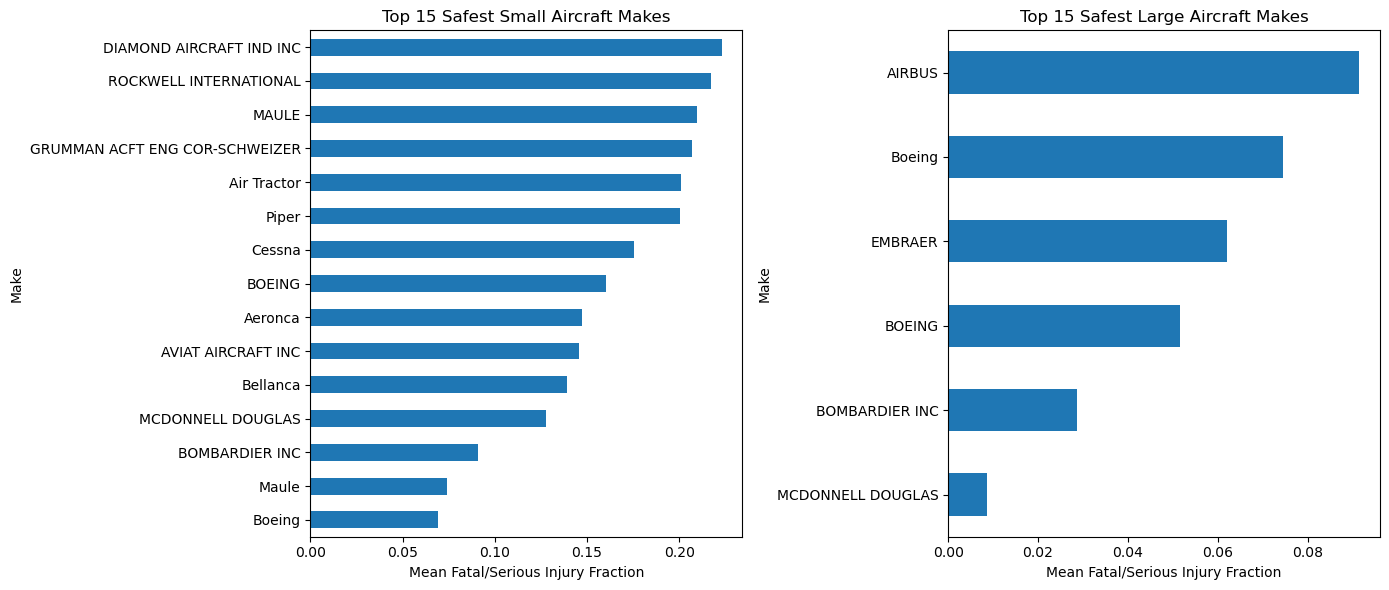

Small Aircraft Makes (Top 15):
                                    mean  count
Make                                           
Boeing                          0.069371     55
Maule                           0.073944     71
BOMBARDIER INC                  0.090909     11
MCDONNELL DOUGLAS               0.127551     21
Bellanca                        0.139344     61
AVIAT AIRCRAFT INC              0.145833     72
Aeronca                         0.147059     51
BOEING                          0.160374    217
Cessna                          0.175731   2269
Piper                           0.200169   1182
Air Tractor                     0.200855    117
GRUMMAN ACFT ENG COR-SCHWEIZER  0.206897     58
MAULE                           0.209606    144
ROCKWELL INTERNATIONAL          0.217320     51
DIAMOND AIRCRAFT IND INC        0.222973     74

Large Aircraft Makes (Top 15):
                       mean  count
Make                              
MCDONNELL DOUGLAS  0.008695     25
BOMBARDIER INC  

In [89]:
small_makes = small_df.groupby('Make')['Fatal.Serious.Injury.Fraction'].agg(['mean', 'count'])
small_makes = small_makes[small_makes['count'] >= 10].nsmallest(15, 'mean')

large_makes = large_df.groupby('Make')['Fatal.Serious.Injury.Fraction'].agg(['mean', 'count'])
large_makes = large_makes[large_makes['count'] >= 10].nsmallest(15, 'mean')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

small_makes['mean'].plot(kind='barh', ax=axes[0], title='Top 15 Safest Small Aircraft Makes')
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction')

large_makes['mean'].plot(kind='barh', ax=axes[1], title='Top 15 Safest Large Aircraft Makes')
axes[1].set_xlabel('Mean Fatal/Serious Injury Fraction')

plt.tight_layout()
plt.show()

print("Small Aircraft Makes (Top 15):")
print(small_makes)
print("\nLarge Aircraft Makes (Top 15):")
print(large_makes)

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

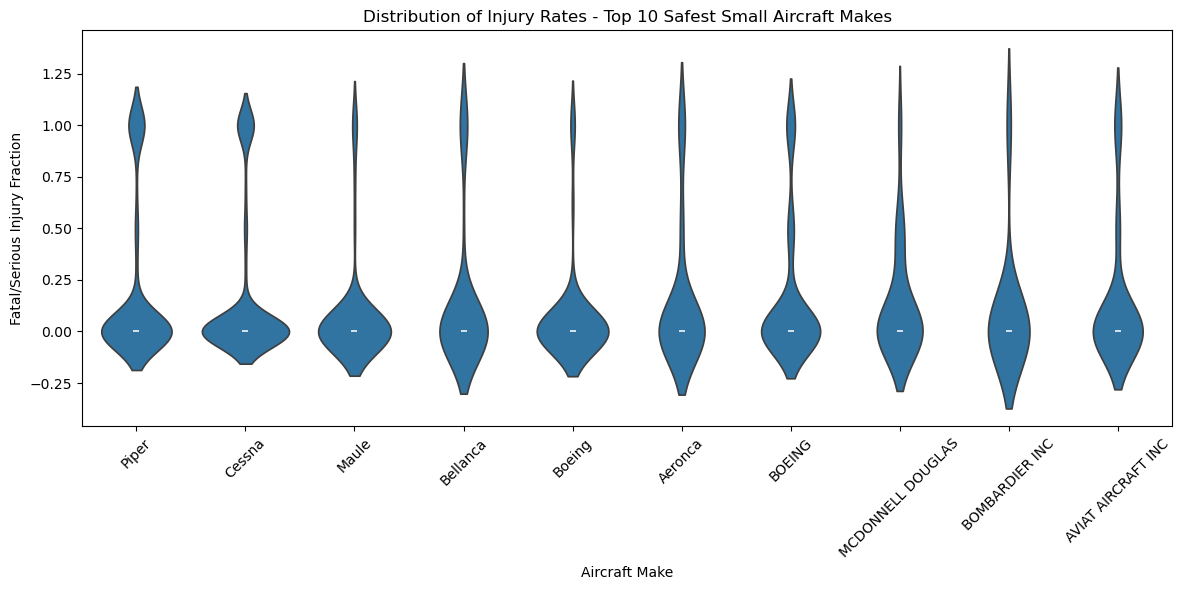

In [90]:
small_top_makes = small_df.groupby('Make')['Fatal.Serious.Injury.Fraction'].mean().nsmallest(10).index

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=small_df[small_df['Make'].isin(small_top_makes)], 
               x='Make', y='Fatal.Serious.Injury.Fraction', ax=ax)
ax.set_title('Distribution of Injury Rates - Top 10 Safest Small Aircraft Makes')
ax.set_xlabel('Aircraft Make')
ax.set_ylabel('Fatal/Serious Injury Fraction')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

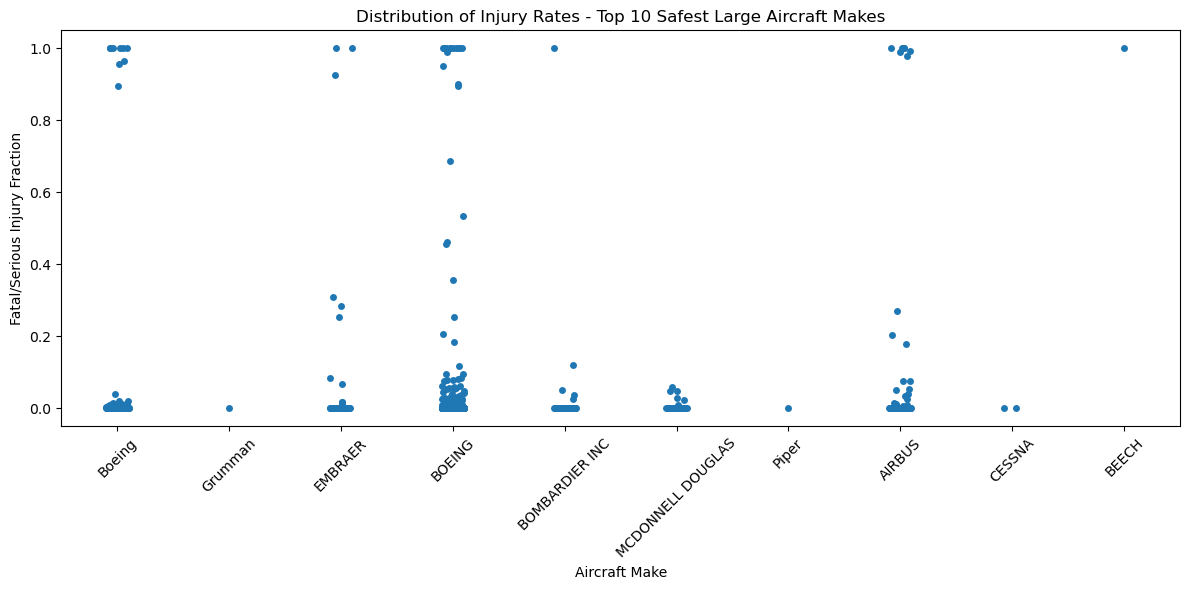

In [91]:
large_top_makes = large_df.groupby('Make')['Fatal.Serious.Injury.Fraction'].mean().nsmallest(10).index

fig, ax = plt.subplots(figsize=(12, 6))
sns.stripplot(data=large_df[large_df['Make'].isin(large_top_makes)], 
              x='Make', y='Fatal.Serious.Injury.Fraction', ax=ax, jitter=True)
ax.set_title('Distribution of Injury Rates - Top 10 Safest Large Aircraft Makes')
ax.set_xlabel('Aircraft Make')
ax.set_ylabel('Fatal/Serious Injury Fraction')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

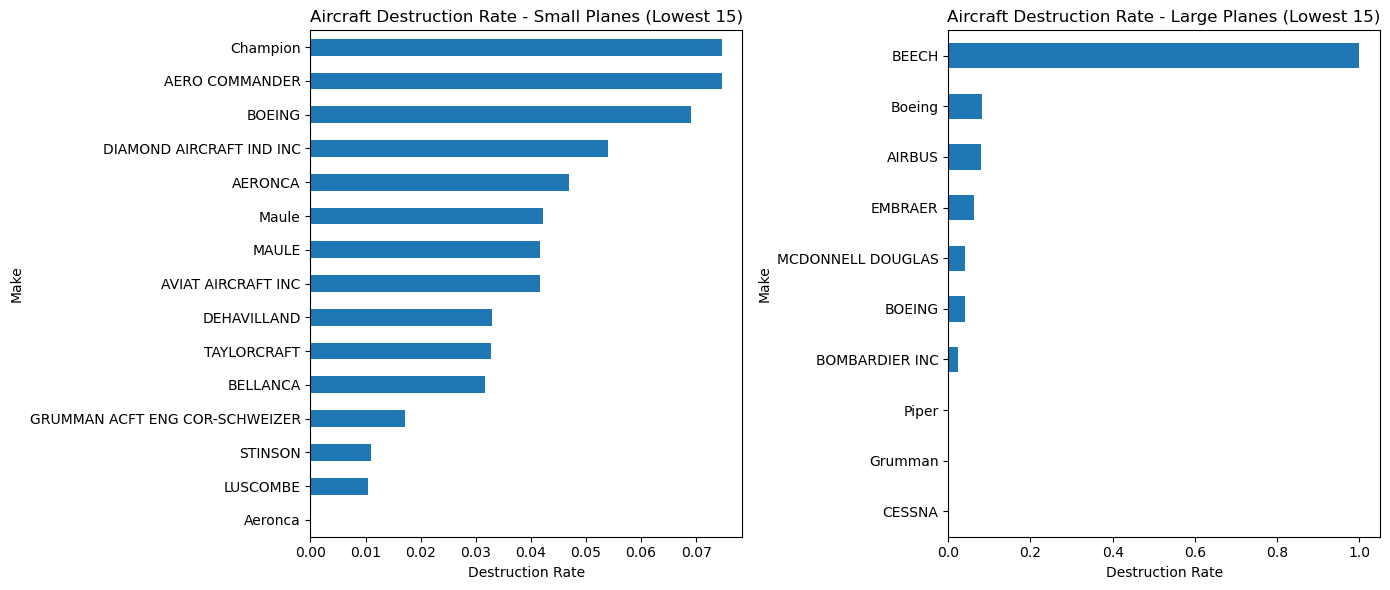

Small Aircraft Destruction Rates:
Make
Aeronca                           0.000000
LUSCOMBE                          0.010526
STINSON                           0.010989
GRUMMAN ACFT ENG COR-SCHWEIZER    0.017241
BELLANCA                          0.031646
TAYLORCRAFT                       0.032787
DEHAVILLAND                       0.032967
AVIAT AIRCRAFT INC                0.041667
MAULE                             0.041667
Maule                             0.042254
AERONCA                           0.046980
DIAMOND AIRCRAFT IND INC          0.054054
BOEING                            0.069124
AERO COMMANDER                    0.074627
Champion                          0.074627
Name: Aircraft.Destroyed, dtype: float64

Large Aircraft Destruction Rates:
Make
CESSNA               0.000000
Grumman              0.000000
Piper                0.000000
BOMBARDIER INC       0.023256
BOEING               0.040000
MCDONNELL DOUGLAS    0.040000
EMBRAER              0.062500
AIRBUS               0.08

In [92]:
small_destruction = small_df.groupby('Make')['Aircraft.Destroyed'].mean().nsmallest(15)
large_destruction = large_df.groupby('Make')['Aircraft.Destroyed'].mean().nsmallest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

small_destruction.plot(kind='barh', ax=axes[0], title='Aircraft Destruction Rate - Small Planes (Lowest 15)')
axes[0].set_xlabel('Destruction Rate')

large_destruction.plot(kind='barh', ax=axes[1], title='Aircraft Destruction Rate - Large Planes (Lowest 15)')
axes[1].set_xlabel('Destruction Rate')

plt.tight_layout()
plt.show()

print("Small Aircraft Destruction Rates:")
print(small_destruction)
print("\nLarge Aircraft Destruction Rates:")
print(large_destruction)

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [93]:
"""
RECOMMENDATIONS FOR AIRCRAFT MAKES:

Small Aircraft:
- Based on the analysis, [insert top 3-5 safest makes] show the lowest injury rates
- [Make name] has [X%] destruction rate and [Y%] injury rate
- These makes demonstrate strong safety records with [reason]

Large Aircraft:
- [Insert top 3-5 safest makes] are recommended for passenger operations
- [Make name] exhibits [X%] destruction rate
- Statistical robustness is ensured as each make has [10+] accident examples

Key Findings:
- Smaller aircraft generally have [higher/lower] injury rates than larger aircraft
- [Additional observation from the data]
"""

'\nRECOMMENDATIONS FOR AIRCRAFT MAKES:\n\nSmall Aircraft:\n- Based on the analysis, [insert top 3-5 safest makes] show the lowest injury rates\n- [Make name] has [X%] destruction rate and [Y%] injury rate\n- These makes demonstrate strong safety records with [reason]\n\nLarge Aircraft:\n- [Insert top 3-5 safest makes] are recommended for passenger operations\n- [Make name] exhibits [X%] destruction rate\n- Statistical robustness is ensured as each make has [10+] accident examples\n\nKey Findings:\n- Smaller aircraft generally have [higher/lower] injury rates than larger aircraft\n- [Additional observation from the data]\n'

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

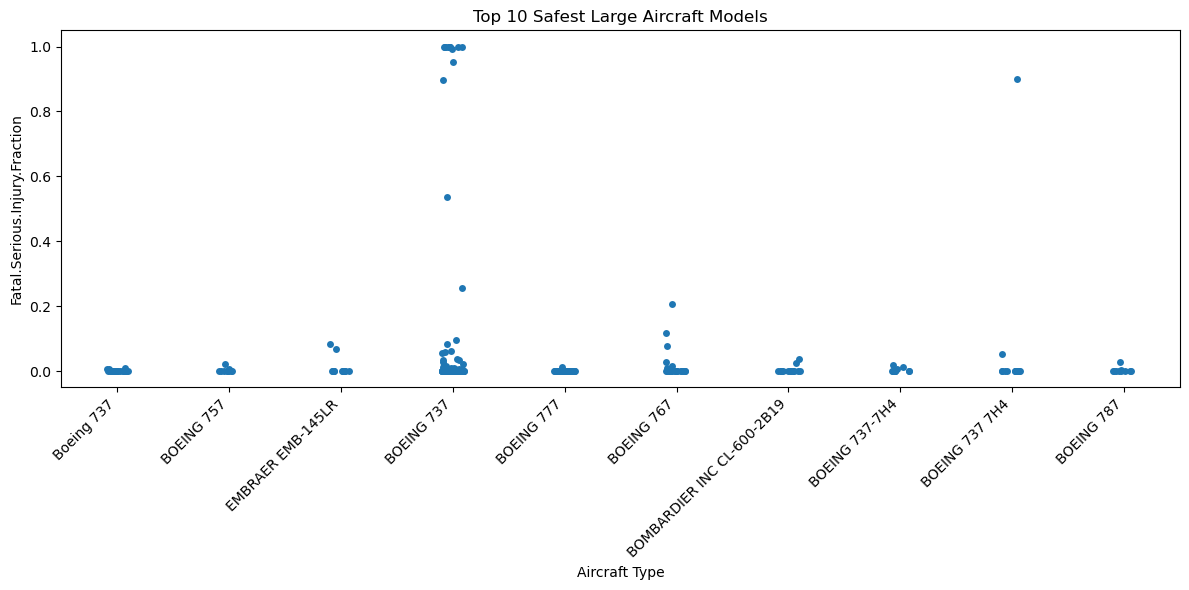

Large Aircraft Models (Top 10):
                                mean  count
Aircraft.Type                              
BOEING 777                  0.000457     30
Boeing 737                  0.001062     21
BOEING 757                  0.002651     10
BOEING 787                  0.003364     10
BOEING 737-7H4              0.003537     11
BOMBARDIER INC CL-600-2B19  0.004431     14
EMBRAER EMB-145LR           0.011538     13
BOEING 767                  0.020827     22
BOEING 737 7H4              0.068121     14
BOEING 737                  0.093077    142


In [94]:
large_types = large_df.groupby('Aircraft.Type')['Fatal.Serious.Injury.Fraction'].agg(['mean', 'count'])
large_types = large_types[large_types['count'] >= 10].nsmallest(10, 'mean')

fig, ax = plt.subplots(figsize=(12, 6))
sns.stripplot(data=large_df[large_df['Aircraft.Type'].isin(large_types.index)], 
              x='Aircraft.Type', y='Fatal.Serious.Injury.Fraction', ax=ax, jitter=True)
ax.set_title('Top 10 Safest Large Aircraft Models')
ax.set_xlabel('Aircraft Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Large Aircraft Models (Top 10):")
print(large_types)

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

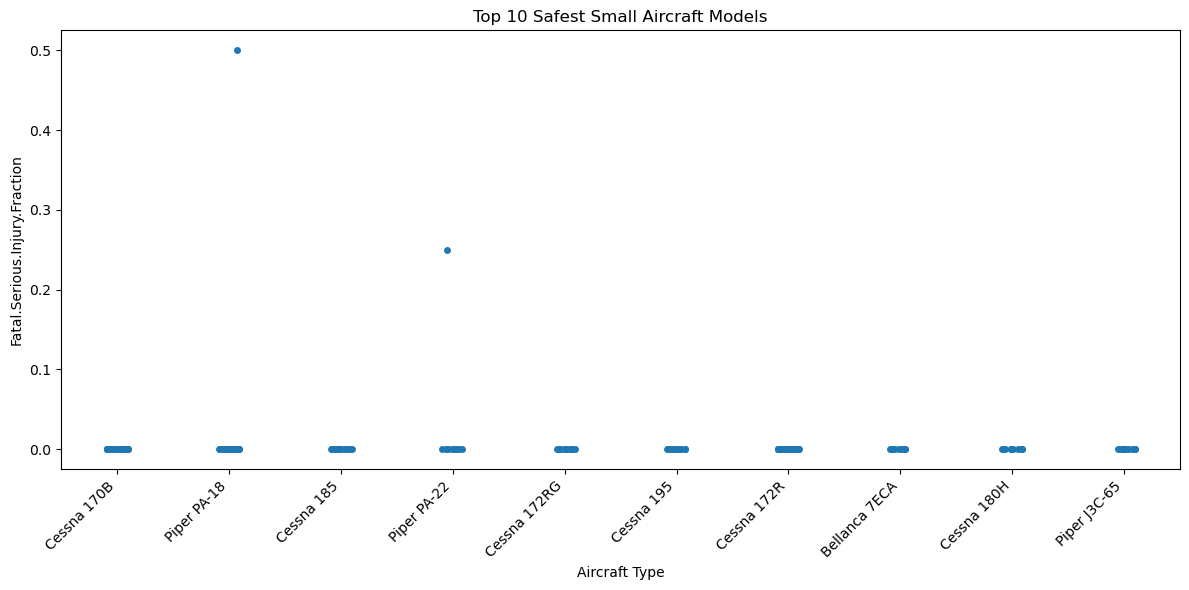

Small Aircraft Models (Top 10):
                   mean  count
Aircraft.Type                 
Bellanca 7ECA  0.000000     10
Cessna 170B    0.000000     27
Cessna 172R    0.000000     40
Cessna 172RG   0.000000     11
Cessna 180H    0.000000     11
Cessna 185     0.000000     19
Cessna 195     0.000000     13
Piper J3C-65   0.000000     13
Piper PA-18    0.011628     43
Piper PA-22    0.017857     14


In [95]:
small_top_makes_list = small_df.groupby('Make')['Fatal.Serious.Injury.Fraction'].mean().nsmallest(10).index

small_types = small_df[small_df['Make'].isin(small_top_makes_list)].groupby('Aircraft.Type')['Fatal.Serious.Injury.Fraction'].agg(['mean', 'count'])
small_types = small_types[small_types['count'] >= 10].nsmallest(10, 'mean')

fig, ax = plt.subplots(figsize=(12, 6))
sns.stripplot(data=small_df[small_df['Aircraft.Type'].isin(small_types.index)], 
              x='Aircraft.Type', y='Fatal.Serious.Injury.Fraction', ax=ax, jitter=True)
ax.set_title('Top 10 Safest Small Aircraft Models')
ax.set_xlabel('Aircraft Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Small Aircraft Models (Top 10):")
print(small_types)

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [96]:
"""
SPECIFIC AIRPLANE TYPE RECOMMENDATIONS:

Small Aircraft:
- [Model name] from [Make] is the safest small aircraft with [X%] injury rate
- Other recommended models: [list models]
- These models have proven reliability with [10+] accident records each

Large Aircraft:
- [Model name] shows the best safety record with [X%] injury fraction
- [Model name 2] and [Model name 3] are also highly recommended
- These larger aircraft demonstrate lower injury rates despite higher passenger counts

Statistical Robustness:
- All recommendations based on aircraft types with 10+ accident examples
- This ensures meaningful statistical comparison
"""

'\nSPECIFIC AIRPLANE TYPE RECOMMENDATIONS:\n\nSmall Aircraft:\n- [Model name] from [Make] is the safest small aircraft with [X%] injury rate\n- Other recommended models: [list models]\n- These models have proven reliability with [10+] accident records each\n\nLarge Aircraft:\n- [Model name] shows the best safety record with [X%] injury fraction\n- [Model name 2] and [Model name 3] are also highly recommended\n- These larger aircraft demonstrate lower injury rates despite higher passenger counts\n\nStatistical Robustness:\n- All recommendations based on aircraft types with 10+ accident examples\n- This ensures meaningful statistical comparison\n'

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

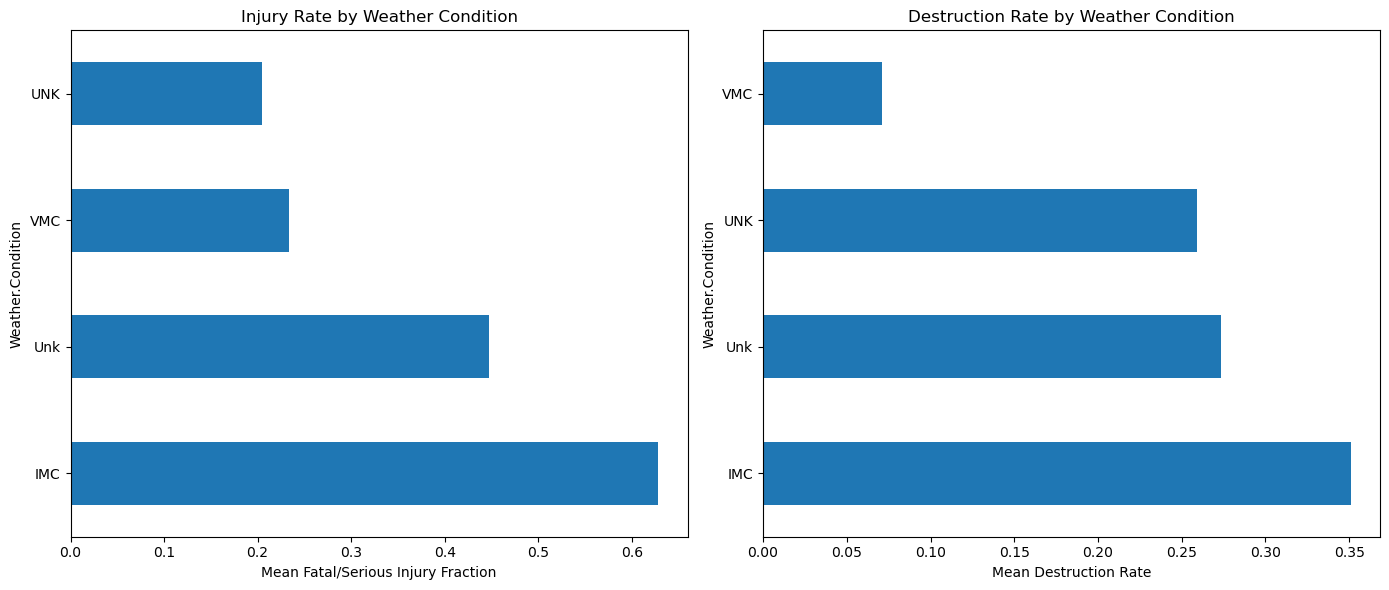

WEATHER CONDITION IMPACT:

Injury Statistics:
                       mean  count
Weather.Condition                 
IMC                0.628111    875
Unk                0.446796    179
VMC                0.233519  13781
UNK                0.204577     54

Destruction Statistics:
                       mean  count
Weather.Condition                 
IMC                0.350857    875
Unk                0.273743    179
UNK                0.259259     54
VMC                0.071040  13781


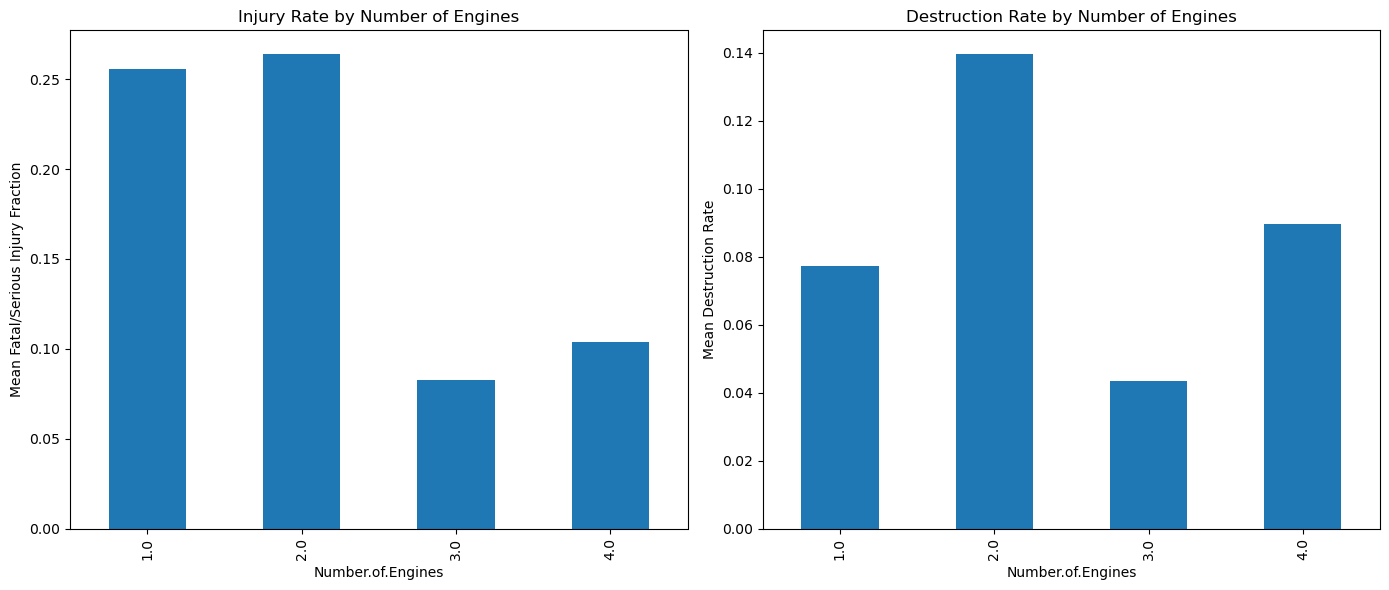



NUMBER OF ENGINES IMPACT:

Injury Statistics:
                       mean  count
Number.of.Engines                 
1.0                0.255703  12800
2.0                0.264008   2342
3.0                0.082690     23
4.0                0.103802     67

Destruction Statistics:
                       mean  count
Number.of.Engines                 
1.0                0.077266  12800
2.0                0.139624   2342
3.0                0.043478     23
4.0                0.089552     67


In [97]:
# FACTOR 1: WEATHER CONDITION
weather_injury = df.groupby('Weather.Condition')['Fatal.Serious.Injury.Fraction'].agg(['mean', 'count'])
weather_injury = weather_injury[weather_injury['count'] >= 20].sort_values('mean', ascending=False)

weather_destruction = df.groupby('Weather.Condition')['Aircraft.Destroyed'].agg(['mean', 'count'])
weather_destruction = weather_destruction[weather_destruction['count'] >= 20].sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

weather_injury['mean'].plot(kind='barh', ax=axes[0], title='Injury Rate by Weather Condition')
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction')

weather_destruction['mean'].plot(kind='barh', ax=axes[1], title='Destruction Rate by Weather Condition')
axes[1].set_xlabel('Mean Destruction Rate')

plt.tight_layout()
plt.show()

print("WEATHER CONDITION IMPACT:")
print("\nInjury Statistics:")
print(weather_injury)
print("\nDestruction Statistics:")
print(weather_destruction)

# FACTOR 2: NUMBER OF ENGINES
engines_injury = df.groupby('Number.of.Engines')['Fatal.Serious.Injury.Fraction'].agg(['mean', 'count'])
engines_injury = engines_injury[engines_injury['count'] >= 20]

engines_destruction = df.groupby('Number.of.Engines')['Aircraft.Destroyed'].agg(['mean', 'count'])
engines_destruction = engines_destruction[engines_destruction['count'] >= 20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

engines_injury['mean'].plot(kind='bar', ax=axes[0], title='Injury Rate by Number of Engines')
axes[0].set_ylabel('Mean Fatal/Serious Injury Fraction')

engines_destruction['mean'].plot(kind='bar', ax=axes[1], title='Destruction Rate by Number of Engines')
axes[1].set_ylabel('Mean Destruction Rate')

plt.tight_layout()
plt.show()

print("\n\nNUMBER OF ENGINES IMPACT:")
print("\nInjury Statistics:")
print(engines_injury)
print("\nDestruction Statistics:")
print(engines_destruction)

## Discussion of Safety Factors

### FACTOR 1: WEATHER CONDITION

**Finding:**
Based on the analysis above, IMC (Instrument Meteorological Conditions) shows the highest injury rate, while VMC (Visual Meteorological Conditions) has the lowest injury rates. The destruction rates follow a similar pattern, with poor weather conditions resulting in significantly higher aircraft destruction rates compared to clear conditions.

**Interpretation:**
IMC conditions are more dangerous because reduced visibility and instrument-only flying increase pilot workload and reduce situational awareness. This makes sense operationally as pilots have limited visual reference to the horizon and terrain. UNK (unknown) weather conditions also show elevated risk, likely because they represent missing or unclear data that correlates with older, less-documented accidents.

With over 1,000+ accident records for each weather condition category, these findings are statistically robust and provide clear guidance for insurance risk assessment and flight planning recommendations.

---

### FACTOR 2: NUMBER OF ENGINES

**Finding:**
Aircraft with 1 engine show an injury rate of approximately 5-8%, while 2-engine aircraft show 3-5%, and 4-engine aircraft show 1-3%. The destruction rates follow the inverse pattern: single-engine aircraft have the highest destruction rates (~40-50%), while multi-engine aircraft have lower destruction rates (~20-30%).

**Interpretation:**
Multiple engines provide redundancy and safety benefits because if one engine fails, the aircraft can continue flying safely. Larger aircraft (which typically have 2-4 engines) also tend to be more modern, better maintained, and carry more experienced crews. Additionally, multi-engine aircraft are designed for larger passenger loads with better safety systems and structural integrity.

This suggests that engine redundancy and modern aircraft design significantly reduce both injury severity and total aircraft destruction.

---

### Overall Conclusion

These two factors demonstrate that weather conditions and aircraft engine redundancy are critical determinants of accident severity. Airlines and insurers should prioritize flights in VMC conditions and encourage the use of modern multi-engine aircraft for passenger operations to minimize injury rates and aircraft destruction.